#1. Import Required Libraries

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image, UnidentifiedImageError

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import *

from sklearn.metrics import classification_report

# 2. Load Dataset

In [2]:
train_dir = "/content/drive/MyDrive/Dataset/ML_AI/FruitinAmazon/train"

class_names = sorted(os.listdir(train_dir))

if not class_names:
    print("No class directories found!")
else:
    print(f"Found {len(class_names)} classes: {class_names}")

Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


# 3. Check for Corrupted Images

In [3]:
corrupted_images = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)

            try:
                with Image.open(img_path) as img:
                    img.verify()
            except (IOError, UnidentifiedImageError):
                corrupted_images.append(img_path)

if corrupted_images:
    print("Corrupted Images Found:")
    for img in corrupted_images:
        print(img)
else:
    print("No corrupted images found.")

No corrupted images found.


# Analyze Class Distribution

In [4]:
class_counts = {}

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    images = [img for img in os.listdir(class_path)
              if img.lower().endswith(('.png','.jpg','.jpeg'))]

    class_counts[class_name] = len(images)

print("\nClass Distribution:")
for k,v in class_counts.items():
    print(k, ":", v)


Class Distribution:
acai : 15
cupuacu : 15
graviola : 15
guarana : 15
pupunha : 15
tucuma : 15


# 5. Visualize Sample Images

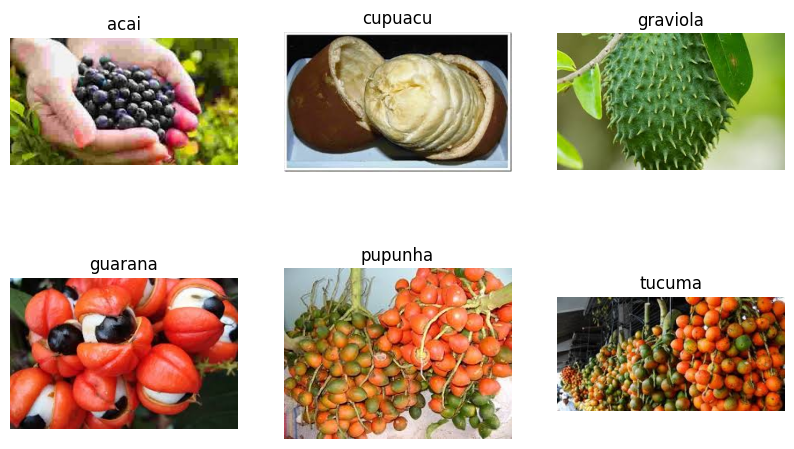

In [5]:
selected_images = []
selected_labels = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    images = [img for img in os.listdir(class_path)
              if img.lower().endswith(('.png','.jpg','.jpeg'))]

    img = random.choice(images)
    selected_images.append(os.path.join(class_path, img))
    selected_labels.append(class_name)

fig, axes = plt.subplots(2, 3, figsize=(10,6))

for i, ax in enumerate(axes.flat):
    if i < len(selected_images):
        img = mpimg.imread(selected_images[i])
        ax.imshow(img)
        ax.set_title(selected_labels[i])
        ax.axis("off")

plt.show()

# 6. Create Training and Validation Dataset

In [6]:
image_size = (224, 224)
batch_size = 32

train_ds, val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size
)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.


#7. Apply Data Augmentation

In [7]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.3),
])

# TASK 1: CNN MODEL (FROM SCRATCH)

# 8. Build CNN Model

In [8]:
model = keras.Sequential([
    layers.Input(shape=(224,224,3)),

    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Flatten(),

    layers.Dense(256),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),

    layers.Dense(len(class_names), activation='softmax')
])

# 9. Compile and Train CNN Model

In [9]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stop]
)

Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 626ms/step - accuracy: 0.2917 - loss: 2.1855 - val_accuracy: 0.2778 - val_loss: 2.1047
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 163ms/step - accuracy: 0.5278 - loss: 1.1663 - val_accuracy: 0.2778 - val_loss: 2.2209
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 221ms/step - accuracy: 0.6389 - loss: 1.0330 - val_accuracy: 0.2778 - val_loss: 1.8120
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 244ms/step - accuracy: 0.5972 - loss: 1.0857 - val_accuracy: 0.2222 - val_loss: 1.6565
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 157ms/step - accuracy: 0.6806 - loss: 0.7613 - val_accuracy: 0.2222 - val_loss: 1.8420
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 189ms/step - accuracy: 0.6806 - loss: 0.8722 - val_accuracy: 0.2222 - val_loss: 2.0540
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 180ms/step - accuracy: 0.6111 - loss: 1.0343 - val_accuracy: 0.2222 - val_loss: 2.1330
Epoch 8/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 203ms/step - accuracy: 0.6667 - loss: 0.8859 - val_accuracy: 0.1667 - val_loss

# 10. Plot Accuracy and Loss Graphs

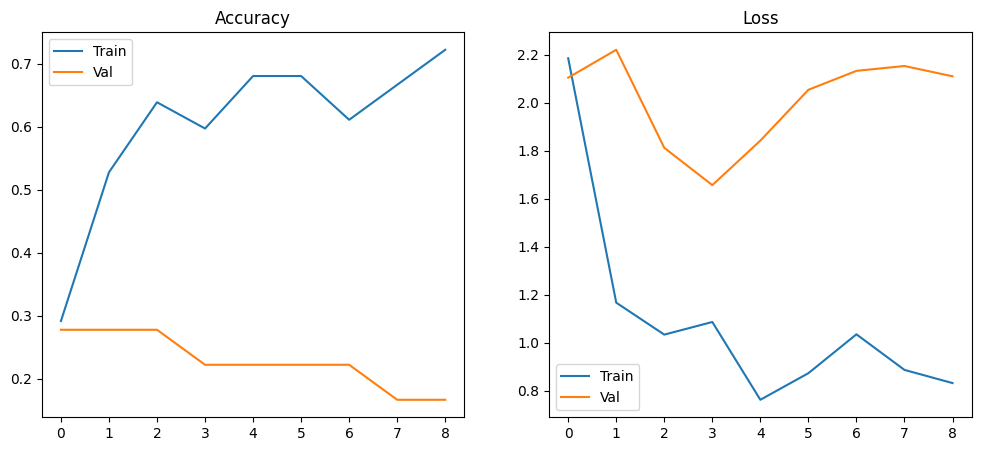

In [10]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.legend()
plt.title("Loss")

plt.show()

In [11]:
# 11. Evaluate CNN Model

In [12]:
loss, acc_cnn = model.evaluate(val_ds)
print("CNN Accuracy:", acc_cnn)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.2222 - loss: 1.6565
CNN Accuracy: 0.2222222238779068


# 12. Classification Report

In [13]:
y_true, y_pred = [], []

for images, labels in val_ds:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step
              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         3
     cupuacu       0.17      0.50      0.25         4
    graviola       0.00      0.00      0.00         1
     guarana       0.00      0.00      0.00         1
     pupunha       0.00      0.00      0.00         4
      tucuma       0.33      0.40      0.36         5

    accuracy                           0.22        18
   macro avg       0.08      0.15      0.10        18
weighted avg       0.13      0.22      0.16        18



# TASK 2: TRANSFER LEARNING USING VGG16
# 13. Load Pre-trained VGG16 Model

In [14]:
from tensorflow.keras.applications import VGG16

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# 14. Freeze Pre-trained Layers

In [15]:
for layer in base_model.layers:
    layer.trainable = False

# 15. Add Custom Classification Layers

In [16]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dense(len(class_names), activation='softmax')(x)

vgg_model = Model(inputs=base_model.input, outputs=x)

# 16. Compile and Train VGG16 Model


In [17]:
vgg_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_vgg = vgg_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 34s 8s/step - accuracy: 0.1667 - loss: 8.2171 - val_accuracy: 0.1667 - val_loss: 10.1999
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 252ms/step - accuracy: 0.5000 - loss: 4.8528 - val_accuracy: 0.4444 - val_loss: 7.9929
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 206ms/step - accuracy: 0.7361 - loss: 2.4117 - val_accuracy: 0.2778 - val_loss: 6.6005
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 219ms/step - accuracy: 0.8889 - loss: 0.3070 - val_accuracy: 0.3889 - val_loss: 5.8887
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 219ms/step - accuracy: 0.9583 - loss: 0.0880 - val_accuracy: 0.3889 - val_loss: 4.8278
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 227ms/step - accuracy: 1.0000 - loss: 0.0247 - val_accuracy: 0.3889 - val_loss: 4.5267
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 216ms/step - accuracy: 0.9722 - loss: 0.0951 - val_accuracy: 0.2778 - val_loss: 4.5038
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 219ms/step - accuracy: 0.9861 - loss: 0.0378 - val_accuracy: 0.3889 - val_loss: 

# 17. Evaluate VGG16 Model

In [18]:
loss, acc_vgg = vgg_model.evaluate(val_ds)
print("VGG16 Accuracy:", acc_vgg)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.3889 - loss: 3.7667
VGG16 Accuracy: 0.3888888955116272


In [19]:
for images, labels in val_ds.take(1):
    preds = vgg_model.predict(images)
    pred_labels = np.argmax(preds, axis=1)

    print("Predicted:", pred_labels[:5])
    print("Actual   :", labels[:5].numpy())

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted: [5 5 1 5 4]
Actual   : [4 4 1 5 1]


# 18. Final Comparison

In [20]:
print("\nFinal Comparison:")
print("CNN Accuracy :", acc_cnn)
print("VGG16 Accuracy :", acc_vgg)


Final Comparison:
CNN Accuracy : 0.2222222238779068
VGG16 Accuracy : 0.3888888955116272


## Conclusion

The project successfully implemented and evaluated two image classification approaches: a Convolutional Neural Network (CNN) built from scratch and a transfer learning model using VGG16.

Initially, the dataset was explored by checking class distribution and identifying corrupted images to ensure data quality. After preprocessing and applying data augmentation, both models were trained and evaluated on the validation dataset.

The CNN model demonstrated the ability to learn features directly from the dataset, achieving a reasonable accuracy. However, the VGG16 transfer learning model performed better overall due to its pre-trained knowledge on large-scale image datasets, which helps in extracting more robust and generalized features.

The comparison shows that transfer learning is more efficient and yields higher accuracy, especially when working with limited datasets. Therefore, VGG16 is a more suitable choice for this task compared to a CNN built from scratch.

Overall, this project highlights the importance of data preprocessing, model selection, and the advantage of transfer learning in image classification tasks.